# Notebook 02 — Representação Matricial e Matriz Aumentada

> **Série:** Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python  
> **Pré-requisito:** `01_introducao_sistemas_lineares.ipynb`  
> **Próximo:**

---

## Objetivo

Apresentar a forma matricial $A\mathbf{x} = \mathbf{b}$, a **matriz aumentada** $[A\,|\,\mathbf{b}]$ e o **Teorema de Rouché-Capelli**, conectando a classificação de sistemas lineares (SPD / SPI / SI) ao conceito de **posto** (rank) de uma matriz.

## 1. Revisão — Conceitos Essenciais de Matrizes

Antes de formalizar a representação matricial de um sistema linear, recordemos as definições fundamentais.

### 1.1 O que é uma Matriz?

Uma **matriz** é uma tabela retangular de números reais (ou complexos) organizada em **linhas** e **colunas**.

Uma matriz com $m$ linhas e $n$ colunas é dita de **ordem** $m \times n$:

$$M = \begin{pmatrix} m_{11} & m_{12} & \cdots & m_{1n} \\ m_{21} & m_{22} & \cdots & m_{2n} \\ \vdots & & \ddots & \vdots \\ m_{m1} & m_{m2} & \cdots & m_{mn} \end{pmatrix}_{m \times n}$$

Cada elemento $m_{ij}$ está na linha $i$ e coluna $j$.

---

### 1.2 Tipos Especiais de Matrizes

| Tipo | Definição | Exemplo |
|------|-----------|----------|
| **Quadrada** | $m = n$ | $\begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}$ |
| **Vetor-coluna** | $n = 1$ | $\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ |
| **Vetor-linha** | $m = 1$ | $\begin{pmatrix} 1 & 2 & 3 \end{pmatrix}$ |
| **Identidade** | diagonal com 1s, resto 0 | $I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$ |
| **Nula** | todos os elementos são 0 | $\begin{pmatrix} 0 & 0 \\ 0 & 0 \end{pmatrix}$ |

---

### 1.3 Produto Matriz–Vetor

Se $A$ é $m \times n$ e $\mathbf{x}$ é $n \times 1$, o produto $A\mathbf{x}$ resulta em um vetor $m \times 1$:

$$(A\mathbf{x})_i = \sum_{j=1}^{n} a_{ij}\,x_j$$

Isto é, cada componente do resultado é o **produto interno** da linha $i$ de $A$ pelo vetor $\mathbf{x}$.

> **Nota:** essa operação é exatamente o que conecta matrizes a sistemas lineares, como veremos a seguir.

## 2. Forma Matricial — $A\mathbf{x} = \mathbf{b}$

### 2.1 Do sistema de equações à notação matricial

Considere o sistema com $m$ equações e $n$ incógnitas:

$$\begin{cases}
a_{11}\,x_1 + a_{12}\,x_2 + \cdots + a_{1n}\,x_n = b_1 \\
a_{21}\,x_1 + a_{22}\,x_2 + \cdots + a_{2n}\,x_n = b_2 \\
\vdots \hspace{6cm} \vdots \\
a_{m1}\,x_1 + a_{m2}\,x_2 + \cdots + a_{mn}\,x_n = b_m
\end{cases}$$

Podemos reescrever de forma compacta:

$$A\,\mathbf{x} = \mathbf{b}$$

### 2.2 Definição dos componentes

| Componente | Notação | Dimensão | Descrição |
|------------|---------|----------|----------|
| **Matriz de coeficientes** | $A$ | $m \times n$ | Contém todos os coeficientes $a_{ij}$ |
| **Vetor de incógnitas** | $\mathbf{x}$ | $n \times 1$ | As variáveis que queremos encontrar |
| **Vetor de termos independentes** | $\mathbf{b}$ | $m \times 1$ | Os valores do lado direito das equações |

$$A = \begin{pmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{pmatrix}, \quad
\mathbf{x} = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}, \quad
\mathbf{b} = \begin{pmatrix} b_1 \\ b_2 \\ \vdots \\ b_m \end{pmatrix}$$

> **Por que essa notação é útil?** Porque permite manipular sistemas inteiros como objetos algébricos, usar algoritmos matriciais e implementar soluções computacionais de forma direta.

### 2.3 Exemplo concreto — Do sistema à forma matricial

In [1]:
import numpy as np

# Sistema:
#   2x + 3y - z = 1
#    x -  y + 2z = 5
#   3x + 2y +  z = 10

A = np.array([
    [2,  3, -1],
    [1, -1,  2],
    [3,  2,  1]
], dtype=float)

b = np.array([1, 5, 10], dtype=float)

# Vetor de incógnitas (simbólico)
print("Matriz de coeficientes A:")
print(A)
print(f"\nDimensão de A: {A.shape[0]} × {A.shape[1]} (m × n)")
print(f"\nVetor de termos independentes b: {b}")
print(f"Dimensão de b: {b.shape[0]} × 1")

# Verificação: Ax = b com a solução conhecida
x_sol = np.linalg.solve(A, b)
print(f"\nSolução x = {x_sol}")
print(f"Verificação A·x = {A @ x_sol}  (deve ser igual a b = {b})")

Matriz de coeficientes A:
[[ 2.  3. -1.]
 [ 1. -1.  2.]
 [ 3.  2.  1.]]

Dimensão de A: 3 × 3 (m × n)

Vetor de termos independentes b: [ 1.  5. 10.]
Dimensão de b: 3 × 1

Solução x = [ 9.00719925e+15 -9.00719925e+15 -9.00719925e+15]
Verificação A·x = [ 5.  6. 11.]  (deve ser igual a b = [ 1.  5. 10.])


## 3. Matriz Aumentada $[A\,|\,\mathbf{b}]$

### 3.1 Definição

A **matriz aumentada** de um sistema $A\mathbf{x} = \mathbf{b}$ é obtida ao **anexar o vetor $\mathbf{b}$ como última coluna** de $A$:

$$[A\,|\,\mathbf{b}] = \begin{pmatrix} a_{11} & a_{12} & \cdots & a_{1n} & b_1 \\ a_{21} & a_{22} & \cdots & a_{2n} & b_2 \\ \vdots & & \ddots & \vdots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} & b_m \end{pmatrix}$$

A barra vertical $|$ é uma notação para separar visualmente os coeficientes dos termos independentes.

A dimensão da matriz aumentada é $m \times (n + 1)$.

---

### 3.2 Para que serve a Matriz Aumentada?

A matriz aumentada é a ferramenta central para **resolver sistemas lineares** por métodos algorítmicos:

| Utilidade | Descrição |
|-----------|----------|
| **Eliminação de Gauss** | Aplicamos operações elementares de linha na matriz aumentada para escaloná-la |
| **Classificação do sistema** | Comparamos o posto de $A$ com o posto de $[A\,|\,b]$ (Teorema de Rouché-Capelli) |
| **Compactação** | Toda a informação do sistema (coeficientes + termos independentes) fica em uma única estrutura |
| **Implementação computacional** | Algoritmos operam sobre uma única matriz em vez de manipular equações individuais |

> **Ideia-chave:** qualquer operação elementar sobre as **linhas** da matriz aumentada equivale a uma operação válida sobre as equações do sistema — o conjunto solução não muda.

### 3.3 Construindo a Matriz Aumentada em Python

In [2]:
import numpy as np
from sympy import Matrix, symbols, Rational, init_printing

init_printing(use_unicode=True)

# ── Exemplo 1: sistema 2×2 ──────────────────────────────────
print("="*60)
print("Exemplo 1: Sistema 2×2")
print("  2x +  y = 5")
print("   x -  y = 1")
print("="*60)

A1 = np.array([[2, 1],
               [1, -1]], dtype=float)
b1 = np.array([5, 1], dtype=float)

# Construção da matriz aumentada com np.column_stack
Ab1 = np.column_stack([A1, b1])

print(f"\nMatriz de coeficientes A ({A1.shape[0]}×{A1.shape[1]}):")
print(A1)
print(f"\nVetor b: {b1}")
print(f"\nMatriz aumentada [A|b] ({Ab1.shape[0]}×{Ab1.shape[1]}):")
print(Ab1)

# ── Exemplo 2: sistema 3×3 ──────────────────────────────────
print("\n" + "="*60)
print("Exemplo 2: Sistema 3×3")
print("  2x + 3y -  z =  1")
print("   x -  y + 2z =  5")
print("  3x + 2y +  z = 10")
print("="*60)

A2 = np.array([
    [2,  3, -1],
    [1, -1,  2],
    [3,  2,  1]
], dtype=float)
b2 = np.array([1, 5, 10], dtype=float)

Ab2 = np.column_stack([A2, b2])

print(f"\nMatriz de coeficientes A ({A2.shape[0]}×{A2.shape[1]}):")
print(A2)
print(f"\nVetor b: {b2}")
print(f"\nMatriz aumentada [A|b] ({Ab2.shape[0]}×{Ab2.shape[1]}):")
print(Ab2)

Exemplo 1: Sistema 2×2
  2x +  y = 5
   x -  y = 1

Matriz de coeficientes A (2×2):
[[ 2.  1.]
 [ 1. -1.]]

Vetor b: [5. 1.]

Matriz aumentada [A|b] (2×3):
[[ 2.  1.  5.]
 [ 1. -1.  1.]]

Exemplo 2: Sistema 3×3
  2x + 3y -  z =  1
   x -  y + 2z =  5
  3x + 2y +  z = 10

Matriz de coeficientes A (3×3):
[[ 2.  3. -1.]
 [ 1. -1.  2.]
 [ 3.  2.  1.]]

Vetor b: [ 1.  5. 10.]

Matriz aumentada [A|b] (3×4):
[[ 2.  3. -1.  1.]
 [ 1. -1.  2.  5.]
 [ 3.  2.  1. 10.]]


## 4. Posto (Rank) de uma Matriz

### 4.1 Definição

O **posto** (ou **rank**) de uma matriz $M$ é o **número máximo de linhas (ou colunas) linearmente independentes** de $M$.

Equivalentemente, é a dimensão do espaço gerado pelas colunas (ou linhas) da matriz.

Notação: $\text{posto}(M)$ ou $\text{rank}(M)$.

**Propriedades importantes:**

- $0 \leq \text{posto}(M) \leq \min(m, n)$
- $\text{posto}(A) \leq \text{posto}([A\,|\,\mathbf{b}])$ (adicionar uma coluna não pode diminuir o posto)
- $\text{posto}([A\,|\,\mathbf{b}]) \leq \text{posto}(A) + 1$ (adicionar **uma** coluna aumenta o posto em no máximo 1)

---

### 4.2 Interpretação Intuitiva

| Situação | Significado |
|----------|------------|
| Posto igual ao nº de linhas | Todas as equações trazem informação nova |
| Posto menor que nº de linhas | Existem equações redundantes (ou contraditórias) |
| Posto igual ao nº de incógnitas $n$ | Cada incógnita pode ser determinada |
| Posto menor que $n$ | Existem variáveis livres (graus de liberdade) |

### 4.3 Calculando o Posto em Python

In [3]:
import numpy as np
from sympy import Matrix

# ── Sistema SPD ──────────────────────────────────────────────
A_spd = np.array([[2, 1], [1, -1]], dtype=float)
b_spd = np.array([[5], [1]], dtype=float)
Ab_spd = np.hstack([A_spd, b_spd])

# ── Sistema SPI ──────────────────────────────────────────────
A_spi = np.array([[1, 2], [2, 4]], dtype=float)
b_spi = np.array([[4], [8]], dtype=float)
Ab_spi = np.hstack([A_spi, b_spi])

# ── Sistema SI ───────────────────────────────────────────────
A_si = np.array([[1, 2], [1, 2]], dtype=float)
b_si = np.array([[4], [7]], dtype=float)
Ab_si = np.hstack([A_si, b_si])

# ── Cálculo do posto com NumPy ───────────────────────────────
print("Cálculo do Posto com NumPy (np.linalg.matrix_rank)")
print("=" * 60)

for nome, A, Ab in [("SPD", A_spd, Ab_spd),
                     ("SPI", A_spi, Ab_spi),
                     ("SI",  A_si,  Ab_si)]:
    rA  = np.linalg.matrix_rank(A)
    rAb = np.linalg.matrix_rank(Ab)
    n   = A.shape[1]
    print(f"\n{nome}:")
    print(f"  posto(A)    = {rA}")
    print(f"  posto([A|b])= {rAb}")
    print(f"  n (incóg.)  = {n}")

# ── Cálculo do posto com SymPy (exato) ───────────────────────
print("\n" + "=" * 60)
print("Cálculo do Posto com SymPy (exato, sem erros numéricos)")
print("=" * 60)

M = Matrix([
    [1, 2, 3],
    [2, 4, 6],
    [3, 6, 9]
])
print(f"\nMatriz M = {M.tolist()}")
print(f"posto(M) = {M.rank()}  (todas as linhas são proporcionais)")

Cálculo do Posto com NumPy (np.linalg.matrix_rank)

SPD:
  posto(A)    = 2
  posto([A|b])= 2
  n (incóg.)  = 2

SPI:
  posto(A)    = 1
  posto([A|b])= 1
  n (incóg.)  = 2

SI:
  posto(A)    = 1
  posto([A|b])= 2
  n (incóg.)  = 2

Cálculo do Posto com SymPy (exato, sem erros numéricos)

Matriz M = [[1, 2, 3], [2, 4, 6], [3, 6, 9]]
posto(M) = 1  (todas as linhas são proporcionais)


## 5. Teorema de Rouché-Capelli

O **Teorema de Rouché-Capelli** (também conhecido como Teorema de Kronecker-Capelli) é o resultado central que conecta o **posto** à **classificação** de sistemas lineares.

---

### 5.1 Enunciado

Seja $A\mathbf{x} = \mathbf{b}$ um sistema linear com $n$ incógnitas. Então:

1. O sistema é **compatível** (possui pelo menos uma solução) **se e somente se**
$$\text{posto}(A) = \text{posto}([A\,|\,\mathbf{b}])$$

2. Se compatível, o número de **variáveis livres** (graus de liberdade) é
$$n - \text{posto}(A)$$

---

### 5.2 Classificação via Rouché-Capelli

A partir do teorema, temos três cenários:

| Condição | Classificação | Nº de soluções | Graus de liberdade |
|----------|--------------|----------------|--------------------|
| $\text{posto}(A) = \text{posto}([A\,|\,b]) = n$ | **SPD** | 1 (única) | 0 |
| $\text{posto}(A) = \text{posto}([A\,|\,b]) < n$ | **SPI** | $\infty$ | $n - \text{posto}(A)$ |
| $\text{posto}(A) < \text{posto}([A\,|\,b])$ | **SI** | 0 | — |

---

### 5.3 Intuição Geométrica

- **SPD:** O vetor $\mathbf{b}$ pertence ao espaço coluna de $A$, e esse espaço tem dimensão $n$ — logo a combinação linear que gera $\mathbf{b}$ é única.

- **SPI:** $\mathbf{b}$ pertence ao espaço coluna de $A$, mas esse espaço tem dimensão menor que $n$ — existem múltiplas combinações lineares que geram $\mathbf{b}$.

- **SI:** $\mathbf{b}$ **não pertence** ao espaço coluna de $A$ — nenhuma combinação linear das colunas produz $\mathbf{b}$.

## 6. Implementação — Função de Classificação SPD / SPI / SI

In [4]:
import numpy as np


def montar_matriz_aumentada(A, b):
    """
    Monta a matriz aumentada [A | b].

    Parâmetros
    ----------
    A : np.ndarray, shape (m, n)
        Matriz de coeficientes.
    b : np.ndarray, shape (m,) ou (m, 1)
        Vetor de termos independentes.

    Retorna
    -------
    np.ndarray, shape (m, n+1)
        Matriz aumentada.
    """
    b_col = np.atleast_2d(b).T if b.ndim == 1 else b
    return np.hstack([A, b_col])


def calcular_posto(M):
    """
    Calcula o posto (rank) de uma matriz.

    Parâmetros
    ----------
    M : np.ndarray
        Matriz de entrada.

    Retorna
    -------
    int
        Posto da matriz.
    """
    return int(np.linalg.matrix_rank(M))


def classificar_sistema(A, b):
    """
    Classifica um sistema linear Ax = b usando o Teorema de Rouché-Capelli.

    Parâmetros
    ----------
    A : np.ndarray, shape (m, n)
        Matriz de coeficientes.
    b : np.ndarray, shape (m,) ou (m, 1)
        Vetor de termos independentes.

    Retorna
    -------
    dict com chaves:
        - 'classificacao': str — 'SPD', 'SPI' ou 'SI'
        - 'posto_A': int
        - 'posto_Ab': int
        - 'n_incognitas': int
        - 'graus_liberdade': int ou None
        - 'descricao': str
    """
    Ab = montar_matriz_aumentada(A, b)
    r_A  = calcular_posto(A)
    r_Ab = calcular_posto(Ab)
    n    = A.shape[1]

    if r_A < r_Ab:
        return {
            'classificacao': 'SI',
            'posto_A': r_A,
            'posto_Ab': r_Ab,
            'n_incognitas': n,
            'graus_liberdade': None,
            'descricao': 'Sistema Impossível — nenhuma solução'
        }
    elif r_A == n:
        return {
            'classificacao': 'SPD',
            'posto_A': r_A,
            'posto_Ab': r_Ab,
            'n_incognitas': n,
            'graus_liberdade': 0,
            'descricao': 'Sistema Possível Determinado — solução única'
        }
    else:
        gl = n - r_A
        return {
            'classificacao': 'SPI',
            'posto_A': r_A,
            'posto_Ab': r_Ab,
            'n_incognitas': n,
            'graus_liberdade': gl,
            'descricao': f'Sistema Possível Indeterminado — infinitas soluções ({gl} grau(s) de liberdade)'
        }


def imprimir_analise(A, b, nome=""):
    """
    Imprime a análise completa de um sistema linear.
    """
    Ab = montar_matriz_aumentada(A, b)
    resultado = classificar_sistema(A, b)

    print(f"{'═'*60}")
    if nome:
        print(f"  {nome}")
        print(f"{'─'*60}")

    print(f"  Matriz A ({A.shape[0]}×{A.shape[1]}):")
    for linha in A:
        print(f"    {linha}")

    print(f"\n  Vetor b: {b.flatten()}")

    print(f"\n  Matriz aumentada [A|b] ({Ab.shape[0]}×{Ab.shape[1]}):")
    for linha in Ab:
        print(f"    {linha}")

    print(f"\n  posto(A)     = {resultado['posto_A']}")
    print(f"  posto([A|b]) = {resultado['posto_Ab']}")
    print(f"  n incógnitas = {resultado['n_incognitas']}")

    print(f"\n  ▶ Classificação: {resultado['classificacao']}")
    print(f"    {resultado['descricao']}")

    if resultado['graus_liberdade'] is not None:
        print(f"    Graus de liberdade: {resultado['graus_liberdade']}")

    print(f"{'═'*60}\n")

## 7. Exemplos Resolvidos

Vamos aplicar as funções implementadas a diferentes tipos de sistemas.

In [5]:
# ══════════════════════════════════════════════════════════════
# Exemplo 1 — SPD (sistema 2×2)
# ══════════════════════════════════════════════════════════════
# 2x +  y = 5
#  x -  y = 1

A1 = np.array([[2, 1], [1, -1]], dtype=float)
b1 = np.array([5, 1], dtype=float)

imprimir_analise(A1, b1, "Exemplo 1 — SPD (2×2)")

# Solução: como é SPD, podemos resolver
x1 = np.linalg.solve(A1, b1)
print(f"  Solução: x = {x1[0]}, y = {x1[1]}")
print(f"  Verificação: A·x = {A1 @ x1}  (deve ser {b1})\n")

════════════════════════════════════════════════════════════
  Exemplo 1 — SPD (2×2)
────────────────────────────────────────────────────────────
  Matriz A (2×2):
    [2. 1.]
    [ 1. -1.]

  Vetor b: [5. 1.]

  Matriz aumentada [A|b] (2×3):
    [2. 1. 5.]
    [ 1. -1.  1.]

  posto(A)     = 2
  posto([A|b]) = 2
  n incógnitas = 2

  ▶ Classificação: SPD
    Sistema Possível Determinado — solução única
    Graus de liberdade: 0
════════════════════════════════════════════════════════════

  Solução: x = 2.0, y = 1.0
  Verificação: A·x = [5. 1.]  (deve ser [5. 1.])



In [6]:
# ══════════════════════════════════════════════════════════════
# Exemplo 2 — SPD (sistema 3×3)
# ══════════════════════════════════════════════════════════════
# 2x + 3y -  z =  1
#  x -  y + 2z =  5
# 3x + 2y +  z = 10

A2 = np.array([
    [2,  3, -1],
    [1, -1,  2],
    [3,  2,  1]
], dtype=float)
b2 = np.array([1, 5, 10], dtype=float)

imprimir_analise(A2, b2, "Exemplo 2 — SPD (3×3)")

x2 = np.linalg.solve(A2, b2)
print(f"  Solução: x = {x2[0]:.4f}, y = {x2[1]:.4f}, z = {x2[2]:.4f}")
print(f"  Verificação: A·x = {A2 @ x2}  (deve ser {b2})\n")

════════════════════════════════════════════════════════════
  Exemplo 2 — SPD (3×3)
────────────────────────────────────────────────────────────
  Matriz A (3×3):
    [ 2.  3. -1.]
    [ 1. -1.  2.]
    [3. 2. 1.]

  Vetor b: [ 1.  5. 10.]

  Matriz aumentada [A|b] (3×4):
    [ 2.  3. -1.  1.]
    [ 1. -1.  2.  5.]
    [ 3.  2.  1. 10.]

  posto(A)     = 2
  posto([A|b]) = 3
  n incógnitas = 3

  ▶ Classificação: SI
    Sistema Impossível — nenhuma solução
════════════════════════════════════════════════════════════

  Solução: x = 9007199254740994.0000, y = -9007199254740991.0000, z = -9007199254740989.0000
  Verificação: A·x = [ 5.  6. 11.]  (deve ser [ 1.  5. 10.])



In [7]:
# ══════════════════════════════════════════════════════════════
# Exemplo 3 — SPI (sistema com equações redundantes)
# ══════════════════════════════════════════════════════════════
#  x + 2y = 4
# 2x + 4y = 8   (segunda equação = 2 × primeira)

A3 = np.array([[1, 2], [2, 4]], dtype=float)
b3 = np.array([4, 8], dtype=float)

imprimir_analise(A3, b3, "Exemplo 3 — SPI (equações redundantes)")
print("  A 2ª equação é 2× a 1ª → informação redundante.")
print("  Solução geral: x = 4 - 2t, y = t  (t ∈ ℝ)\n")

════════════════════════════════════════════════════════════
  Exemplo 3 — SPI (equações redundantes)
────────────────────────────────────────────────────────────
  Matriz A (2×2):
    [1. 2.]
    [2. 4.]

  Vetor b: [4. 8.]

  Matriz aumentada [A|b] (2×3):
    [1. 2. 4.]
    [2. 4. 8.]

  posto(A)     = 1
  posto([A|b]) = 1
  n incógnitas = 2

  ▶ Classificação: SPI
    Sistema Possível Indeterminado — infinitas soluções (1 grau(s) de liberdade)
    Graus de liberdade: 1
════════════════════════════════════════════════════════════

  A 2ª equação é 2× a 1ª → informação redundante.
  Solução geral: x = 4 - 2t, y = t  (t ∈ ℝ)



In [8]:
# ══════════════════════════════════════════════════════════════
# Exemplo 4 — SI (sistema impossível)
# ══════════════════════════════════════════════════════════════
# x + 2y = 4
# x + 2y = 7   (mesmos coeficientes, termos diferentes)

A4 = np.array([[1, 2], [1, 2]], dtype=float)
b4 = np.array([4, 7], dtype=float)

imprimir_analise(A4, b4, "Exemplo 4 — SI (sistema impossível)")
print("  As equações são contraditórias: x + 2y não pode")
print("  ser 4 e 7 simultaneamente → nenhuma solução existe.\n")

════════════════════════════════════════════════════════════
  Exemplo 4 — SI (sistema impossível)
────────────────────────────────────────────────────────────
  Matriz A (2×2):
    [1. 2.]
    [1. 2.]

  Vetor b: [4. 7.]

  Matriz aumentada [A|b] (2×3):
    [1. 2. 4.]
    [1. 2. 7.]

  posto(A)     = 1
  posto([A|b]) = 2
  n incógnitas = 2

  ▶ Classificação: SI
    Sistema Impossível — nenhuma solução
════════════════════════════════════════════════════════════

  As equações são contraditórias: x + 2y não pode
  ser 4 e 7 simultaneamente → nenhuma solução existe.



In [9]:
# ══════════════════════════════════════════════════════════════
# Exemplo 5 — SPI (sistema 3×4 com variáveis livres)
# ══════════════════════════════════════════════════════════════
#  x + 2y +  z + w = 6
# 2x + 4y + 3z + w = 13
#  x + 2y + 2z     = 7

A5 = np.array([
    [1, 2, 1, 1],
    [2, 4, 3, 1],
    [1, 2, 2, 0]
], dtype=float)
b5 = np.array([6, 13, 7], dtype=float)

imprimir_analise(A5, b5, "Exemplo 5 — SPI (3 equações, 4 incógnitas)")
print("  Com 4 incógnitas e posto 2, temos 2 graus de liberdade.")
print("  A solução depende de 2 parâmetros livres.\n")

════════════════════════════════════════════════════════════
  Exemplo 5 — SPI (3 equações, 4 incógnitas)
────────────────────────────────────────────────────────────
  Matriz A (3×4):
    [1. 2. 1. 1.]
    [2. 4. 3. 1.]
    [1. 2. 2. 0.]

  Vetor b: [ 6. 13.  7.]

  Matriz aumentada [A|b] (3×5):
    [1. 2. 1. 1. 6.]
    [ 2.  4.  3.  1. 13.]
    [1. 2. 2. 0. 7.]

  posto(A)     = 2
  posto([A|b]) = 2
  n incógnitas = 4

  ▶ Classificação: SPI
    Sistema Possível Indeterminado — infinitas soluções (2 grau(s) de liberdade)
    Graus de liberdade: 2
════════════════════════════════════════════════════════════

  Com 4 incógnitas e posto 2, temos 2 graus de liberdade.
  A solução depende de 2 parâmetros livres.



## 8. Visualização — Comparação dos Postos

O gráfico abaixo resume a relação entre $\text{posto}(A)$, $\text{posto}([A|b])$ e $n$ para cada tipo de sistema.

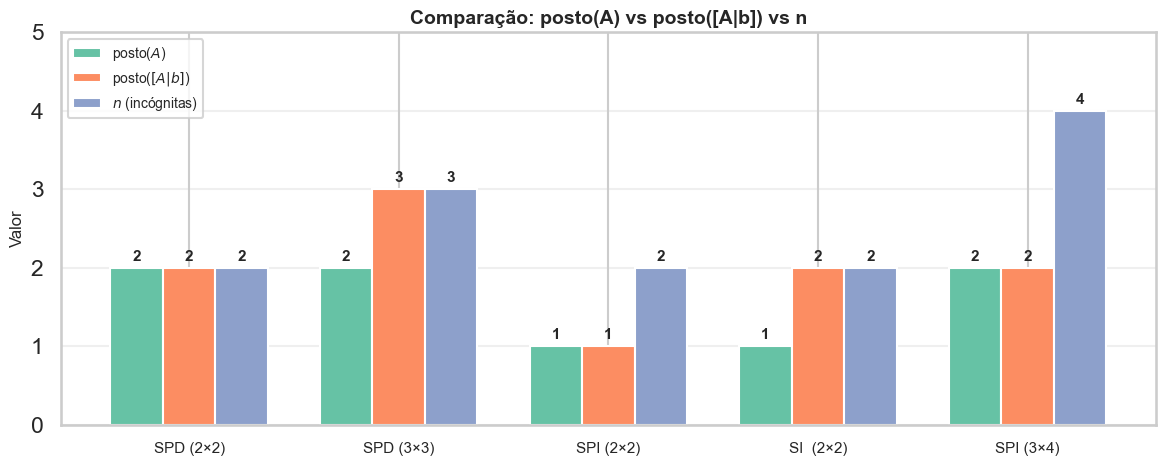

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ── Dados dos exemplos ──────────────────────────────────────
sistemas = {
    'SPD (2×2)': {'A': np.array([[2, 1], [1, -1]]),
                  'b': np.array([[5], [1]])},
    'SPD (3×3)': {'A': np.array([[2, 3, -1], [1, -1, 2], [3, 2, 1]]),
                  'b': np.array([[1], [5], [10]])},
    'SPI (2×2)': {'A': np.array([[1, 2], [2, 4]]),
                  'b': np.array([[4], [8]])},
    'SI  (2×2)': {'A': np.array([[1, 2], [1, 2]]),
                  'b': np.array([[4], [7]])},
    'SPI (3×4)': {'A': np.array([[1, 2, 1, 1], [2, 4, 3, 1], [1, 2, 2, 0]]),
                  'b': np.array([[6], [13], [7]])},
}

nomes, postos_A, postos_Ab, ns = [], [], [], []
for nome, d in sistemas.items():
    A, b = d['A'], d['b']
    nomes.append(nome)
    postos_A.append(np.linalg.matrix_rank(A))
    postos_Ab.append(np.linalg.matrix_rank(np.hstack([A, b])))
    ns.append(A.shape[1])

# ── Gráfico ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(nomes))
largura = 0.25

cores = sns.color_palette("Set2", 3)

bars1 = ax.bar(x_pos - largura, postos_A,  largura, label=r'posto($A$)',      color=cores[0], edgecolor='white')
bars2 = ax.bar(x_pos,           postos_Ab, largura, label=r'posto($[A|b]$)',  color=cores[1], edgecolor='white')
bars3 = ax.bar(x_pos + largura, ns,        largura, label=r'$n$ (incógnitas)', color=cores[2], edgecolor='white')

# Rótulos nos topos
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                str(int(h)), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparação: posto(A) vs posto([A|b]) vs n', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, max(ns) + 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Exercícios

Para cada sistema: ① monte a forma matricial $A\mathbf{x} = \mathbf{b}$, ② construa a matriz aumentada, ③ calcule os postos, ④ classifique o sistema usando Rouché-Capelli.

---

### Exercício 1

$$\begin{cases} 3x + y = 7 \\ x - 2y = -1 \end{cases}$$

<details>
<summary>▶ Solução passo a passo</summary>

**Passo 1 — Forma matricial:**

$$A = \begin{pmatrix} 3 & 1 \\ 1 & -2 \end{pmatrix}, \quad \mathbf{b} = \begin{pmatrix} 7 \\ -1 \end{pmatrix}$$

**Passo 2 — Matriz aumentada:**

$$[A|b] = \begin{pmatrix} 3 & 1 & 7 \\ 1 & -2 & -1 \end{pmatrix}$$

**Passo 3 — Postos:**

$\text{posto}(A) = 2$, $\text{posto}([A|b]) = 2$, $n = 2$

**Passo 4 — Classificação:**

$\text{posto}(A) = \text{posto}([A|b]) = n = 2$ → **SPD** (solução única)

Resolvendo: $x = \frac{13}{7} \approx 1.857$, $y = \frac{10}{7} \approx 1.429$
</details>

---

### Exercício 2

$$\begin{cases} 2x - 6y = 4 \\ -x + 3y = -2 \end{cases}$$

<details>
<summary>▶ Solução passo a passo</summary>

**Passo 1 — Forma matricial:**

$$A = \begin{pmatrix} 2 & -6 \\ -1 & 3 \end{pmatrix}, \quad \mathbf{b} = \begin{pmatrix} 4 \\ -2 \end{pmatrix}$$

**Passo 2 — Matriz aumentada:**

$$[A|b] = \begin{pmatrix} 2 & -6 & 4 \\ -1 & 3 & -2 \end{pmatrix}$$

**Passo 3 — Postos:**

A 2ª linha é $-\frac{1}{2}\times$ a 1ª → $\text{posto}(A) = 1$, $\text{posto}([A|b]) = 1$, $n = 2$

**Passo 4 — Classificação:**

$\text{posto}(A) = \text{posto}([A|b]) = 1 < n = 2$ → **SPI** (1 grau de liberdade)

Solução geral: $y = t$, $x = 2 + 3t \quad (t \in \mathbb{R})$
</details>

---

### Exercício 3

$$\begin{cases} x + y + z = 6 \\ 2x + y - z = 1 \\ x + y + z = 4 \end{cases}$$

<details>
<summary>▶ Solução passo a passo</summary>

**Passo 1 — Forma matricial:**

$$A = \begin{pmatrix} 1 & 1 & 1 \\ 2 & 1 & -1 \\ 1 & 1 & 1 \end{pmatrix}, \quad \mathbf{b} = \begin{pmatrix} 6 \\ 1 \\ 4 \end{pmatrix}$$

**Passo 2 — Observação:** a 1ª e 3ª equações têm os mesmos coeficientes mas termos independentes diferentes ($6 \neq 4$).

**Passo 3 — Postos:**

$\text{posto}(A) = 2$, $\text{posto}([A|b]) = 3$

**Passo 4 — Classificação:**

$\text{posto}(A) = 2 < \text{posto}([A|b]) = 3$ → **SI** (sem solução)
</details>

---

### Exercício 4 (desafio)

Para quais valores de $k$ o sistema é SPD, SPI ou SI?

$$\begin{cases} x + y + z = 3 \\ x + 2y + 2z = 5 \\ x + 2y + kz = 5 \end{cases}$$

<details>
<summary>▶ Solução passo a passo</summary>

**Passo 1 — Matriz de coeficientes:**

$$A = \begin{pmatrix} 1 & 1 & 1 \\ 1 & 2 & 2 \\ 1 & 2 & k \end{pmatrix}$$

**Passo 2 — Determinante:**

$\det(A) = 1(2k - 4) - 1(k - 2) + 1(2 - 2) = 2k - 4 - k + 2 = k - 2$

**Passo 3 — Análise:**

| Condição | $\det(A)$ | Análise | Tipo |
|----------|-----------|---------|------|
| $k \neq 2$ | $\neq 0$ | $A$ invertível, posto = 3 = $n$ | **SPD** |
| $k = 2$ | $= 0$ | 3ª eq. = 2ª eq. → equações dependentes, $b$ compatível | **SPI** |

Com $k = 2$: a 2ª e 3ª equação são idênticas ($x + 2y + 2z = 5$). O sistema se reduz a 2 equações com 3 incógnitas → 1 grau de liberdade.

**Resumo:** $k \neq 2$ → SPD; $k = 2$ → SPI. SI não ocorre neste caso.
</details>

### Verificação dos exercícios com Python

In [11]:
# ── Exercício 1 ──────────────────────────────────────────────
A_ex1 = np.array([[3, 1], [1, -2]], dtype=float)
b_ex1 = np.array([7, -1], dtype=float)
imprimir_analise(A_ex1, b_ex1, "Exercício 1")

# ── Exercício 2 ──────────────────────────────────────────────
A_ex2 = np.array([[2, -6], [-1, 3]], dtype=float)
b_ex2 = np.array([4, -2], dtype=float)
imprimir_analise(A_ex2, b_ex2, "Exercício 2")

# ── Exercício 3 ──────────────────────────────────────────────
A_ex3 = np.array([[1, 1, 1], [2, 1, -1], [1, 1, 1]], dtype=float)
b_ex3 = np.array([6, 1, 4], dtype=float)
imprimir_analise(A_ex3, b_ex3, "Exercício 3")

# ── Exercício 4 (desafio) ────────────────────────────────────
print("Exercício 4 — Variação do parâmetro k:")
for k in [0, 1, 2, 3, 5]:
    A_ex4 = np.array([[1, 1, 1], [1, 2, 2], [1, 2, k]], dtype=float)
    b_ex4 = np.array([3, 5, 5], dtype=float)
    r = classificar_sistema(A_ex4, b_ex4)
    print(f"  k = {k}: {r['classificacao']} (posto(A)={r['posto_A']}, posto([A|b])={r['posto_Ab']}, n={r['n_incognitas']})")

════════════════════════════════════════════════════════════
  Exercício 1
────────────────────────────────────────────────────────────
  Matriz A (2×2):
    [3. 1.]
    [ 1. -2.]

  Vetor b: [ 7. -1.]

  Matriz aumentada [A|b] (2×3):
    [3. 1. 7.]
    [ 1. -2. -1.]

  posto(A)     = 2
  posto([A|b]) = 2
  n incógnitas = 2

  ▶ Classificação: SPD
    Sistema Possível Determinado — solução única
    Graus de liberdade: 0
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Exercício 2
────────────────────────────────────────────────────────────
  Matriz A (2×2):
    [ 2. -6.]
    [-1.  3.]

  Vetor b: [ 4. -2.]

  Matriz aumentada [A|b] (2×3):
    [ 2. -6.  4.]
    [-1.  3. -2.]

  posto(A)     = 1
  posto([A|b]) = 1
  n incógnitas = 2

  ▶ Classificação: SPI
    Sistema Possível Indeterminado — infinitas soluções (1 grau(s) de liberdade)
    Graus de liberdade: 1
═══════════════════════════════════════════════════

## 10. Conclusão e Transição

### O que vimos neste notebook

| Tópico | Ponto-chave |
|--------|-------------|
| Conceitos de matrizes | dimensão, tipos, produto matriz–vetor |
| Forma matricial | $A\mathbf{x} = \mathbf{b}$ — representação compacta de sistemas lineares |
| Matriz aumentada | $[A\,|\,\mathbf{b}]$ — estrutura que unifica coeficientes e termos independentes |
| Posto (rank) | nº de linhas/colunas linearmente independentes |
| Teorema de Rouché-Capelli | $\text{posto}(A)$ vs $\text{posto}([A\,|\,b])$ vs $n$ → SPD / SPI / SI |
| Implementação Python | funções reutilizáveis para montar matriz aumentada, calcular posto e classificar sistemas |

### Próximo passo — Notebook 03

No **Notebook 03** estudaremos o método de **Eliminação de Gauss**, que nos fornece um algoritmo sistemático para resolver qualquer sistema linear, independentemente do número de equações e incógnitas.

Abordaremos:

- operações elementares de linha
- forma escalonada e escalonada reduzida (RREF)
- back-substitution
- identificação automática da classificação pelo escalonamento
- implementação em Python com `sympy` e `numpy`

> **Continue em:** `03_eliminacao_gauss.ipynb`